<div style='color:rgb(0, 0, 0);
           background-color:rgb(240, 186, 8);
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
Projet: Churn ...
<a class="anchor" id="1"></a> 

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd

In [3]:
df= pd.read_csv('../data/churn/churn_1.csv')

In [ ]:
df.sample(5)

In [5]:
# transform the field chunr? to binary
df['Churn?']= (df['Churn?']=='True.').astype(int)

In [6]:
df['Churn?'].value_counts()

Churn?
0    2850
1     483
Name: count, dtype: int64

In [7]:
X=df.drop('Churn?', axis=1)
y=df['Churn?']

In [8]:
#      تحميل البيانات

# X = pd.read_csv('./data/churn_features.csv', index_col=0)
# y=pd.read_csv('./data/churn_target.csv', index_col=0)

In [9]:
# تقسيم البيانات :  تدريب &  اختبار
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y  ,test_size=.33, random_state=42)

In [10]:
!pip install -U scikit-learn

In [11]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import make_column_transformer , make_column_selector  as selector
# from sklearn.compose import

from sklearn.pipeline import make_pipeline


num_pipeline= make_pipeline(
     StandardScaler()    # تغيير سلم البيانات الرقمية
)

cat_pipeline= make_pipeline(
     OneHotEncoder(drop="if_binary", sparse_output=False)  #   بما ان جميع القيم الناقصة قد تم تعويضا فلا فائدة من معالجتها لذا نقوم هنا باسقاط احد العمودين في حالة المتغير الثنائي

)

preprocess= make_column_transformer(
     ( num_pipeline,  selector(dtype_include="number") ),  #توظيف  سلسة معالجة الباينات أعلاه على جميع البيانات الرقمية
     (cat_pipeline, selector(dtype_exclude="number")) , #category  كان بالامكان تغيير  نوع المتغيرات الى تصنيف
     remainder="passthrough"  # واسقاط باقي البيانات الغير رقمية
     )

In [12]:
# حجم البيانات الجديد
preprocess.fit_transform(X_train).shape

(2233, 70)

In [13]:
# التحقق من تحويل  البيانات
preprocess.fit_transform(X_train)

array([[ 0.70927833, -0.81498972, -0.51621471, ...,  0.        ,
         0.        ,  0.        ],
       [-0.28389262,  0.76425984, -0.51621471, ...,  0.        ,
         0.        ,  1.        ],
       [-0.29227381, -0.33870811,  1.7389225 , ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.40751516, -0.86512463, -0.68238272, ...,  0.        ,
         0.        ,  0.        ],
       [-0.86219469,  1.71682307, -0.51621471, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.56206435, -1.61714823, -0.68238272, ...,  0.        ,
         0.        ,  1.        ]], shape=(2233, 70))

In [14]:
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
pipe_XGBCl= make_pipeline(
    preprocess,    # تغيير سلم البيانات الرقمية
    XGBClassifier()
)

In [15]:
#pipeline  معايير
list(pipe_XGBCl.get_params().keys())

['memory',
 'steps',
 'transform_input',
 'verbose',
 'columntransformer',
 'xgbclassifier',
 'columntransformer__force_int_remainder_cols',
 'columntransformer__n_jobs',
 'columntransformer__remainder',
 'columntransformer__sparse_threshold',
 'columntransformer__transformer_weights',
 'columntransformer__transformers',
 'columntransformer__verbose',
 'columntransformer__verbose_feature_names_out',
 'columntransformer__pipeline-1',
 'columntransformer__pipeline-2',
 'columntransformer__pipeline-1__memory',
 'columntransformer__pipeline-1__steps',
 'columntransformer__pipeline-1__transform_input',
 'columntransformer__pipeline-1__verbose',
 'columntransformer__pipeline-1__standardscaler',
 'columntransformer__pipeline-1__standardscaler__copy',
 'columntransformer__pipeline-1__standardscaler__with_mean',
 'columntransformer__pipeline-1__standardscaler__with_std',
 'columntransformer__pipeline-2__memory',
 'columntransformer__pipeline-2__steps',
 'columntransformer__pipeline-2__transform

In [16]:
from sklearn import set_config
set_config(display='diagram', )

In [17]:
param_grid = {
   'xgbclassifier__n_estimators': [50, 100, 150, 200],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.2, 0.3],
    'xgbclassifier__max_depth': range(3, 5),
    'xgbclassifier__colsample_bytree': [i/10.0 for i in range(1, 3)],
    'xgbclassifier__gamma': [i/10.0 for i in range(3)],
    'xgbclassifier__scale_pos_weight': [1, 10, 25, 50, 75, 99, 100, 1000],


}

- Generally, scale_pos_weight is the ratio of number of negative class to the positive class.

Suppose, the dataset has 90 observations of negative class and 10 observations of positive class, then ideal value of scale_pos_weight should be 9.

In [18]:
# Define cross validation
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, random_state=42, shuffle=True)


In [19]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc, make_scorer, recall_score, accuracy_score, precision_score, confusion_matrix, roc_auc_score
scorers = {
    'precision_score': make_scorer(precision_score),
    'recall_score': make_scorer(recall_score),
    'accuracy_score': make_scorer(accuracy_score ),
    'roc_auc': make_scorer(roc_auc_score)
}

### RandomizedSearchCV

![](https://adventuresindatascience.files.wordpress.com/2017/10/bb_rcv.png)

In [20]:
# %%timeit
from sklearn.model_selection import RandomizedSearchCV
RdSearch = RandomizedSearchCV(pipe_XGBCl, param_distributions=param_grid, cv=kf, verbose=3,
                                n_jobs=-1 ,scoring= scorers   , n_iter=100 , refit="roc_auc" )

In [21]:
# التدريب
RdSearch.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


[CV 2/5] END xgbclassifier__colsample_bytree=0.2, xgbclassifier__gamma=0.1, xgbclassifier__learning_rate=0.2, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=200, xgbclassifier__scale_pos_weight=99; accuracy_score: (test=0.899) precision_score: (test=0.595) recall_score: (test=0.820) roc_auc: (test=0.866) total time=   0.3s
[CV 1/5] END xgbclassifier__colsample_bytree=0.2, xgbclassifier__gamma=0.1, xgbclassifier__learning_rate=0.2, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=200, xgbclassifier__scale_pos_weight=99; accuracy_score: (test=0.875) precision_score: (test=0.506) recall_score: (test=0.754) roc_auc: (test=0.823) total time=   0.3s
[CV 3/5] END xgbclassifier__colsample_bytree=0.2, xgbclassifier__gamma=0.1, xgbclassifier__learning_rate=0.2, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=200, xgbclassifier__scale_pos_weight=99; accuracy_score: (test=0.906) precision_score: (test=0.711) recall_score: (test=0.766) roc_auc: (test=0.851) total time=   0.2

/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV 1/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.2, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=200, xgbclassifier__scale_pos_weight=1; accuracy_score: (test=0.872) precision_score: (test=0.000) recall_score: (test=0.000) roc_auc: (test=0.500) total time=   0.2s
[CV 2/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.2, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=200, xgbclassifier__scale_pos_weight=1; accuracy_score: (test=0.864) precision_score: (test=0.000) recall_score: (test=0.000) roc_auc: (test=0.500) total time=   0.2s
[CV 3/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.2, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=200, xgbclassifier__scale_pos_weight=1; accuracy_score: (test=0.828) precision_score: (test=0.000) recall_score: (test=0.000) roc_auc: (test=0.500) total time=   0.2

/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV 3/5] END xgbclassifier__colsample_bytree=0.2, xgbclassifier__gamma=0.1, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=150, xgbclassifier__scale_pos_weight=1; accuracy_score: (test=0.828) precision_score: (test=0.000) recall_score: (test=0.000) roc_auc: (test=0.500) total time=   0.1s
[CV 5/5] END xgbclassifier__colsample_bytree=0.2, xgbclassifier__gamma=0.1, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=150, xgbclassifier__scale_pos_weight=1; accuracy_score: (test=0.865) precision_score: (test=0.000) recall_score: (test=0.000) roc_auc: (test=0.499) total time=   0.1s
[CV 4/5] END xgbclassifier__colsample_bytree=0.2, xgbclassifier__gamma=0.1, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=150, xgbclassifier__scale_pos_weight=1; accuracy_score: (test=0.848) precision_score: (test=1.000) recall_score: (test=0.014) roc_auc: (test=0.507) total time=   0.1

/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12

[CV 1/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.0, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=50, xgbclassifier__scale_pos_weight=1; accuracy_score: (test=0.872) precision_score: (test=0.000) recall_score: (test=0.000) roc_auc: (test=0.500) total time=   0.1s
[CV 5/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.0, xgbclassifier__learning_rate=0.3, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=100, xgbclassifier__scale_pos_weight=1000; accuracy_score: (test=0.451) precision_score: (test=0.184) recall_score: (test=0.915) roc_auc: (test=0.648) total time=   0.1s
[CV 2/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.0, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=50, xgbclassifier__scale_pos_weight=1; accuracy_score: (test=0.864) precision_score: (test=0.000) recall_score: (test=0.000) roc_auc: (test=0.500) total time=   0.1

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('pipeline-1',
                                                                               Pipeline(steps=[('standardscaler',
                                                                                                StandardScaler())]),
                                                                               <sklearn.compose._column_transformer.make_column_selector object at 0x7419b367d550>),
                                                                              ('pipeline-2',
                                                                               Pipeline(steps...
                                        'xgbclassifier__scale_pos_weight': [1,
                                                                            10,
                                                                            25,
                                                                            50,
                                                                            75,
                                                                            99,
                                                                            100,
                                                                            1000]},
                   refit='roc_auc',
                   scoring={'accuracy_score': make_scorer(accuracy_score, response_method='predict'),
                            'precision_score': make_scorer(precision_score, response_method='predict'),
                            'recall_score': make_scorer(recall_score, response_method='predict'),
                            'roc_auc': make_scorer(roc_auc_score, response_method='predict')},
                   verbose=3)

In [22]:
# افضل المعايير التي تم الاحتفاظ بها
RdSearch.best_params_

{'xgbclassifier__scale_pos_weight': 10,
 'xgbclassifier__n_estimators': 200,
 'xgbclassifier__max_depth': 4,
 'xgbclassifier__learning_rate': 0.1,
 'xgbclassifier__gamma': 0.0,
 'xgbclassifier__colsample_bytree': 0.2}

In [23]:
#  قائمة أفضل المعاييير
RdSearch.best_estimator_

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline-1',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7419b4642b40>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 sparse_output=False))]),
                                                  <skle...
                               feature_types=None, feature_weights=None,
                               gamma=0.0, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [24]:
# قياس الدقة في ضوء أفضل المعايير
f" Score {RdSearch.best_estimator_.score(X_test, y_test):.3}"

' Score 0.918'

In [25]:
y_pred=RdSearch.predict(X_test)
f'Accuracy: {accuracy_score(y_test, y_pred):.3}'

'Accuracy: 0.918'

- Recall
Recall goes another route. Instead of looking at the number of false positives the model predicted, recall looks at the number of false negatives that were thrown into the prediction mix.
$$ Recall = \frac{TP}{TP + FN}$$

![](https://newbiettn.github.io/images/confusion-matrix-noted.jpg)


In [26]:
# نسبة التنبؤ  بالمقارنة مع القيم الأصلية
f'Accuracy: {recall_score(y_test, y_pred):.3}'

'Accuracy: 0.812'

In [27]:
#  Precision / recall  بين    F1  يوازن معيار القيس
from sklearn import metrics
f'Accuracy: {metrics.f1_score(y_test, y_pred):.3}'

'Accuracy: 0.743'

In [28]:
#
f"Performance sur le train : {roc_auc_score(y_train, RdSearch.predict(X_train))} "

'Performance sur le train : 0.9877190280907072 '

In [29]:
# overfitting problem
f"Performance sur le train : {roc_auc_score(y_test, RdSearch.predict(X_test)):0.3} "

'Performance sur le train : 0.874 '

In [30]:
f"Performance sur le Test : {recall_score(y_test, RdSearch.predict(X_test)):0.3} "

'Performance sur le Test : 0.812 '

<Axes: >

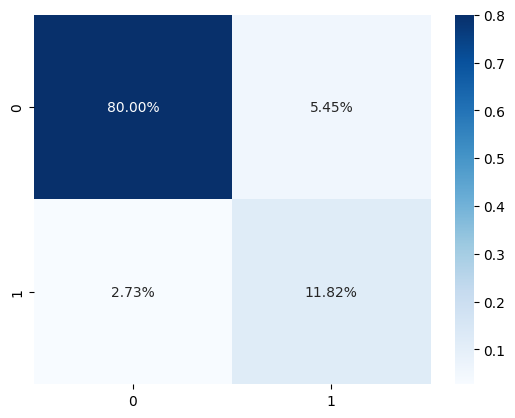

In [31]:
#  Confusion Matrix
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, y_pred)
import seaborn as sns
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True,
            fmt='.2%', cmap='Blues')
# print a formated  confusion matrix


# confusion_matrix(y_test, y_pred ) #, normalize=True)

In [32]:
# skplt.metrics.plot_confusion_matrix(y_test, y_pred ) #, normalize=True)

In [33]:
from sklearn import metrics
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95       940
           1       0.68      0.81      0.74       160

    accuracy                           0.92      1100
   macro avg       0.83      0.87      0.85      1100
weighted avg       0.93      0.92      0.92      1100



Text(0.5, 1.0, 'ROC Curve')

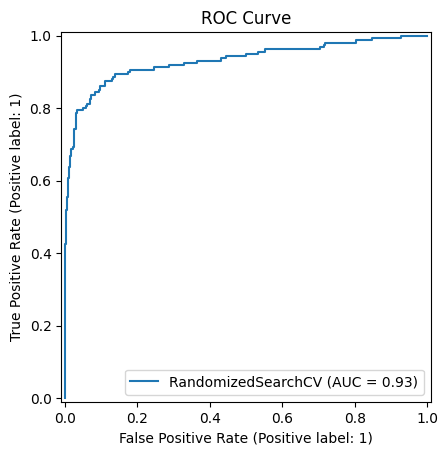

In [34]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
# Plot the ROC curve
RocCurveDisplay.from_estimator(RdSearch, X_test, y_test)
plt.title("ROC Curve")


In [35]:
#AUC    قياس درجة  دقة  التنبؤ لمعيار
f'Best AUC Score: {RdSearch.best_score_ :.3}'


'Best AUC Score: 0.855'

In [36]:
# جدول الأحتمالات
y_probas = RdSearch.predict_proba(X_test)


In [37]:
y_probas

array([[0.48327821, 0.5167218 ],
       [0.9590992 , 0.0409008 ],
       [0.06197518, 0.9380248 ],
       ...,
       [0.90890557, 0.09109442],
       [0.05445707, 0.94554293],
       [0.47865063, 0.5213494 ]], shape=(1100, 2), dtype=float32)

In [38]:
((y_probas>0.5)+0)

array([[0, 1],
       [1, 0],
       [0, 1],
       ...,
       [1, 0],
       [0, 1],
       [0, 1]], shape=(1100, 2))

In [39]:
y_pred

array([1, 0, 1, ..., 0, 1, 1], shape=(1100,))

In [40]:
#  اشتقاق جدول التنبؤات
((y_probas>0.5)+0)[:,1]

array([1, 0, 1, ..., 0, 1, 1], shape=(1100,))

<Axes: >

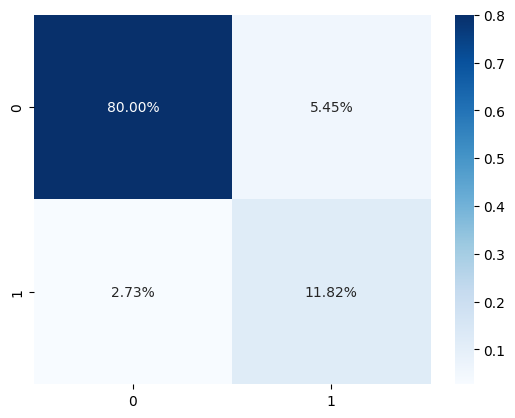

In [41]:
cf_matrix = confusion_matrix(y_test, ((y_probas>0.5)+0)[:,1])
import seaborn as sns
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True,
            fmt='.2%', cmap='Blues')

-  اسوء نتيجة هي تلك التي تنبأ بها النموذج على أن العميل لن يقطع عقده مع شركة الاتصالات ولكنه  على عكس المتوقع قطعه.
- لذا فإن الشكرة مستعدة لتفعيل حزمة من التدابير مثا تمتيع العميل بترقية للخدمات حتى تبقي عليه .

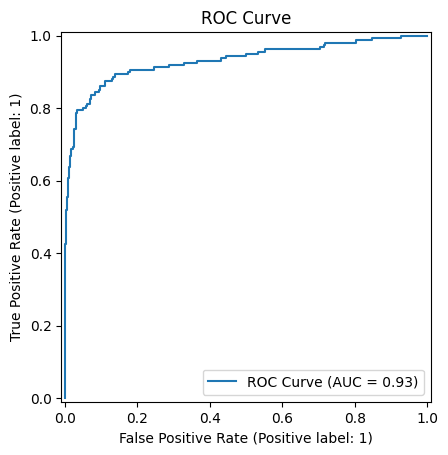

In [42]:
RocCurveDisplay.from_predictions(y_test, y_probas[:, 1], name="ROC Curve")
plt.title("ROC Curve")
plt.show()

![](https://www.researchgate.net/profile/Md_Ashraful_Amin/publication/220176738/figure/fig4/AS:669969142534168@1536744499664/The-confusion-matrix-left-and-the-calculation-of-true-positive-rate-false-positive.png)

- The ROC in the figure has a high AUC. We can also see there’s a point on the graph where TPR(sensitivity) is quite high and FPR(1-specificity) is dramatically low. If we go back and look at our business need, we needed a high TPR and low FPR that is exactly what we are getting from that point on this ROC. The threshold corresponding to that point can be said to be the best threshold value.
https://towardsdatascience.com/demystifying-confusion-matrix-29f3037b0cfa

- F1-Score
In practice, when we try to increase the precision of our model, the recall goes down, and vice-versa. The F1-score captures both the trends in a single value:

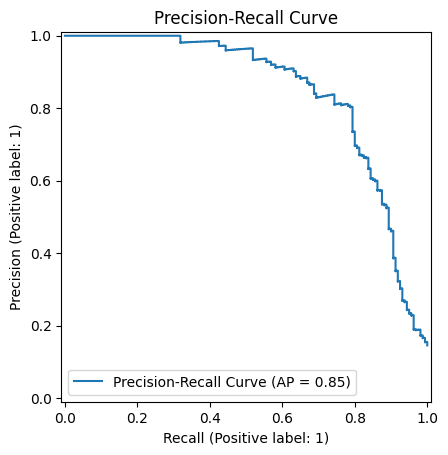

In [43]:
# skplt.metrics.plot_precision_recall_curve(y_test, y_probas, figsize=(10, 8))
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(RdSearch, X_test, y_test, name="Precision-Recall Curve")
plt.title("Precision-Recall Curve")
plt.show()

In [44]:
from sklearn.metrics import roc_curve

# Assuming y_test and y_probas_positive exist
y_probas_positive = y_probas[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probas_positive)
optimal_idx = np.argmax(tpr - fpr) # Find index of max KS statistic (TPR - FPR)
best_threshold = thresholds[optimal_idx]

print(f"Best threshold ): {best_threshold}")

Best threshold ): 0.45992979407310486


Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 2/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.0, xgbclassifier__learning_rate=0.1, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=50, xgbclassifier__scale_pos_weight=99; accuracy_score: (test=0.168) precision_score: (test=0.141) recall_score: (test=1.000) roc_auc: (test=0.518) total time=   0.1s
[CV 1/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.0, xgbclassifier__learning_rate=0.1, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=50, xgbclassifier__scale_pos_weight=99; accuracy_score: (test=0.172) precision_score: (test=0.130) recall_score: (test=0.965) roc_auc: (test=0.511) total time=   0.1s
[CV 3/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.0, xgbclassifier__learning_rate=0.1, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=50, xgbclassifier__scale_pos_weight=99; accuracy_score: (test=0.213) precision_score: (test=0.178) recall

/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12

[CV 1/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.2, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=200, xgbclassifier__scale_pos_weight=1; accuracy_score: (test=0.872) precision_score: (test=0.000) recall_score: (test=0.000) roc_auc: (test=0.500) total time=   0.2s
[CV 3/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.2, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=200, xgbclassifier__scale_pos_weight=1; accuracy_score: (test=0.828) precision_score: (test=0.000) recall_score: (test=0.000) roc_auc: (test=0.500) total time=   0.1s
[CV 4/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.2, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=200, xgbclassifier__scale_pos_weight=1; accuracy_score: (test=0.845) precision_score: (test=0.000) recall_score: (test=0.000) roc_auc: (test=0.500) total time=   0.1

/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV 4/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.0, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=100, xgbclassifier__scale_pos_weight=99; accuracy_score: (test=0.155) precision_score: (test=0.155) recall_score: (test=1.000) roc_auc: (test=0.500) total time=   0.1s
[CV 1/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.0, xgbclassifier__learning_rate=0.1, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=150, xgbclassifier__scale_pos_weight=10; accuracy_score: (test=0.812) precision_score: (test=0.385) recall_score: (test=0.789) roc_auc: (test=0.802) total time=   0.1s
[CV 2/5] END xgbclassifier__colsample_bytree=0.1, xgbclassifier__gamma=0.0, xgbclassifier__learning_rate=0.1, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=150, xgbclassifier__scale_pos_weight=10; accuracy_score: (test=0.817) precision_score: (test=0.417) recall_score: (test=0.869) roc_auc: (test=0.839) total time=   0.

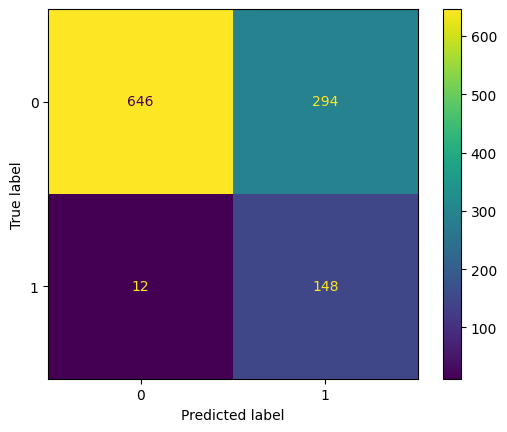

In [45]:
from sklearn.model_selection import FixedThresholdClassifier
from sklearn.metrics import ConfusionMatrixDisplay

classifier_01 = FixedThresholdClassifier(RdSearch, threshold=0.3)
classifier_01.fit(X_train, y_train)
_ = ConfusionMatrixDisplay.from_estimator(classifier_01, X_test, y_test)

![](https://newbiettn.github.io/images/confusion-matrix-noted.jpg)

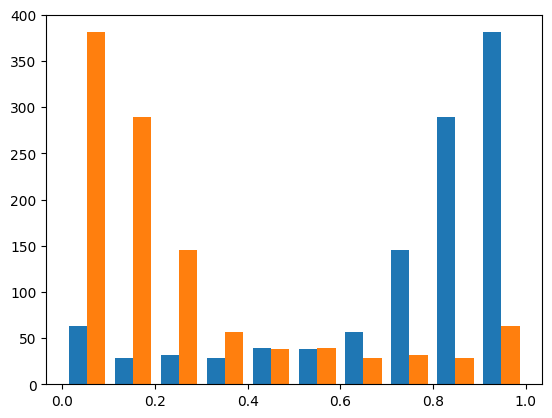

In [46]:
import matplotlib.pyplot as plt

plt.hist(y_probas , bins=10)
plt.show()

- Now coming to the business part, the Telecom company efficiently is balancing between reducing Churners (increasing TPR) and reducing wrong classification of good customers as probable Churners (lowering FPR).
- Therefore the organisation in this case can’t just rely on the **Accuracy** of the model.   

In [47]:
metrics.confusion_matrix(y_test, ((y_probas>0.3)+0)[:,1])

array([[796, 144],
       [ 17, 143]])

- Finding the optimal cutoff¶
It’s clear that false negatives are substantially more costly than false positives. Instead of optimizing for error based on the number of customers, we should be minimizing a cost function that looks like this:

قيمة الخسائر التي ستنمى بها شركة الاتصالات   في حالة مغادرة حرفائها

Cost  = $500 * FN(C) + $0 * TN(C) + $100 * FP(C) + $100 * TP(C)
FN(C) means that the fal

In [48]:
np.array([[0, 100], [500, 100]])

array([[  0, 100],
       [500, 100]])

- Matrix Multiplication
![](https://upload.wikimedia.org/wikipedia/commons/thumb/e/eb/Matrix_multiplication_diagram_2.svg/313px-Matrix_multiplication_diagram_2.svg.png)

In [49]:
 np.array([[0, 100], [500, 100]])*metrics.confusion_matrix(y_test, ((y_probas>0.3)+0)[:,1])

array([[    0, 14400],
       [ 8500, 14300]])

In [50]:
#
np.sum(np.array([[0, 100], [500, 100]]) *
                               metrics.confusion_matrix(y_test, ((y_probas>0.3)+0)[:,1])
                               )

np.int64(37200)

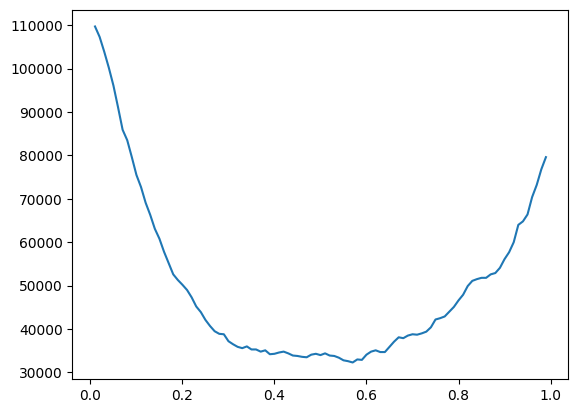

Cost is minimized near a cutoff of: 0.5700000000000001 for a cost of: 32300


In [51]:
cutoffs = np.arange(0.01, 1, 0.01)
costs = []
for c in cutoffs:
    costs.append(
        np.sum(np.array([[0, 100], [500, 100]]) *
                               metrics.confusion_matrix(y_test, ((y_probas>c)+0)[:,1])
                               )
        )


costs = np.array(costs)
plt.plot(cutoffs, costs)
plt.show()
print('Cost is minimized near a cutoff of:', cutoffs[np.argmin(costs)], 'for a cost of:', np.min(costs))

-   0.5  يتضح لنا أن افضل معيار لتحديد جدول التنبؤات والذي يقلل من تلكفة  خسار شركة الاتصالات من خلال مغادرة العملاء هو

Displaying Confusion Matrix for threshold = 0.6


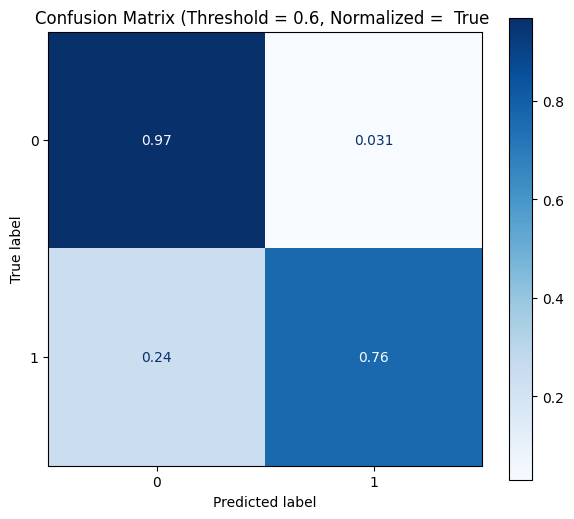

In [53]:
custom_threshold = 0.6
y_pred_custom = (y_probas_positive >= custom_threshold).astype(int)

# 3. Plot the confusion matrix using ConfusionMatrixDisplay
print(f"Displaying Confusion Matrix for threshold = {custom_threshold}")

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_custom,
    normalize="true",
    cmap=plt.cm.Blues,
    ax=ax )

ax.set_title(f'Confusion Matrix (Threshold = {custom_threshold}, Normalized =  True ')
plt.show()